# Mercado de trabajo de IA: México vs Estados Unidos
## 04 — El modelo
### DA: *Mau Vilar*
#### https://github.com/mauvilar

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, "..")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from src.analysis.stats import resumir_por, mediana_ci
from src.analysis.hypothesis import mann_whitney, welch_log
from src.viz.estilo import (
    PALETA, aplicar_estilo, colores, componer, etiquetar, miles, porcentaje, rejilla,
)

# Gráficas en Editorial v3 (src/viz/estilo.py): fondo rich-black, neutros para el
# contexto y verde sólo para lo que dice el hallazgo.
aplicar_estilo()
FUENTE = "Fuente: API de Adzuna (snapshot del 10 ago 2026) y Kaggle, mannacharya/ai-job-listings · cálculos propios"
FUENTE_MODELO = "Fuente: corpus propio (API de Adzuna y Kaggle, mannacharya/ai-job-listings) · modelo HistGradientBoosting · cálculos propios"
df = pd.read_parquet("../data/processed/vacantes.parquet")
print(f"{len(df):,} vacantes | {df['salary_observed'].sum():,} con salario observado")
df.head()

6,990 vacantes | 1,666 con salario observado


,posting_id,snapshot_date,source,title_raw,title_norm,company,company_posting_count,company_is_multinational,category,country,...,salary_observed,salary_annual_local,salary_annual_usd,salary_annual_usd_ppp,seniority,tier,skills,description_text,description_lang,url
0,11a69e030bbeb53ec642d827a5ccb1d8f42cd050,2026-08-10,adzuna_mx,RPA Engineer AI Development Experience,rpa engineer ai development experience,AllianceIT Inc,1,False,Unknown,MX,...,True,81000.0,4722.701619,7842.035459,unknown,nucleo,[],"Design, build, test, and deploy Intelligent Ag...",en,https://www.adzuna.com.mx/land/ad/5797062930?s...
1,4c34441a2388bd88259480834442d16d021b0801,2026-08-10,adzuna_mx,Machine Learning Engineer,machine learning engineer,Capital Empresarial Horizonte,6,False,Unknown,MX,...,True,600000.0,34982.974952,58089.151551,unknown,nucleo,"[python, pytorch, tensorflow]",Capital Empresarial Horizonte Empresa Mexicana...,es,https://www.adzuna.com.mx/land/ad/5768169505?s...
2,32f1656a91bd124277eb9ae53e24af7614d2ded7,2026-08-10,adzuna_mx,Ingeniero de Preventa Google Cloud e Inteligen...,ingeniero de preventa google cloud e inteligen...,Capital Empresarial Horizonte,6,False,Unknown,MX,...,True,60000.0,3498.297495,5808.915155,unknown,nucleo,"[gcp, llm]",Capital Empresarial Horizonte Empresa Mexicana...,es,https://www.adzuna.com.mx/land/ad/5800080170?s...
3,33043115125a4d46c1cf05caf42ff7b764f4bbce,2026-08-10,adzuna_mx,Ingeniero en Inteligencia Artificial,ingeniero en inteligencia artificial,Grupo Financiero Inbursa Corporativo,1,False,Unknown,MX,...,True,240000.0,13993.189981,23235.660620,unknown,nucleo,[],Únete al equipo de Innovación de Grupo Finan...,es,https://www.adzuna.com.mx/land/ad/5812515682?s...
4,45f0e4c23e486ef2663196c229a4ac09670eb1ed,2026-08-10,adzuna_mx,Maestra de Matemáticas o Inteligencia Artific...,maestra de matemáticas o inteligencia artific...,VARFRA,1,False,Empleos en educación,MX,...,True,180000.0,10494.892486,17426.745465,unknown,fuera,[],Vacante Descripción del empleo Estamos en bú...,es,https://www.adzuna.com.mx/land/ad/5774880912?s...


## Por qué un modelo

Los notebooks anteriores establecieron el problema: en México casi nadie publica el salario de
una vacante de IA. De las 45 vacantes mexicanas que la taxonomía núcleo/anillo reconoce como
genuinamente de IA, sólo 4 traen un número. Con 4 observaciones no hay mediana que reportar con
seriedad — el propio criterio del proyecto exige n ≥ 30 para publicar un estadístico descriptivo
(notebooks 01–03), y México no lo alcanza ni de cerca.

La pregunta de este notebook es si un modelo puede rodear ese muro: Estados Unidos sí publica
salario en cantidad (cientos de vacantes de IA con sueldo observado) y comparte con México el
mismo vocabulario de puestos, seniority y skills. Si la relación entre esos atributos y el salario
tuviera una forma parecida en ambos países —aunque el *nivel* sea distinto—, un modelo entrenado
en EE.UU. podría estimar el salario de una vacante mexicana a partir de su título, su seniority,
sus skills, su empresa.

Es una hipótesis, no un hecho, y tratarla como un hecho sería el error exacto que este proyecto
existe para evitar. Por eso el resto del notebook no se conforma con entrenar el modelo: lo
entrena **sin ver un solo dato mexicano**, y luego lo somete a un examen fijado de antemano
(§7 del spec: MdAPE ≤ 35 % y superar a un baseline ingenuo) contra cada salario mexicano real que
tenemos. Si el modelo pasa, sus estimaciones se publican. Si no, el hallazgo es el resultado.

**Conclusión:** en lugar de preguntar directamente «¿cuánto paga México?», este notebook pregunta
algo más disciplinado — ¿puede un modelo entrenado donde el salario sí se ve adivinar el salario
donde no se ve, y podemos demostrarlo? Lo que sigue construye el modelo; la sección de evaluación
es donde se gana, o no, el derecho a que le creamos.

## Preparación

El corpus completo tiene 6,990 vacantes, pero no todas son de IA: la búsqueda por palabras clave
en Adzuna también trae abogados, técnicos de HVAC y gerentes de RRHH que mencionan «AI» de pasada
(ver notebook 01). La taxonomía núcleo/anillo/fuera ya separa las vacantes genuinamente
relacionadas con IA (núcleo + anillo) del ruido de búsqueda (fuera). Entrenar un modelo salarial
sobre ese ruido diluiría la señal antes de empezar, así que todo lo que sigue trabaja únicamente
sobre el subconjunto de IA.

In [2]:
import warnings; warnings.filterwarnings("ignore", category=FutureWarning)

from src.models.impute import FEATURES, TARGET, entrenar, particionar, preparar
from src.models.evaluate import evaluar_holdout_mx, baseline_pais_seniority, mdape
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold, cross_val_predict

ia = df[df["tier"] != "fuera"].copy()
print(f"Vacantes de IA (núcleo + anillo): {len(ia):,} de {len(df):,} totales")
print(ia.groupby("country").size().rename("vacantes_IA"))
print()
print(f"México, de esas: {len(ia[ia['country'] == 'MX']):,}")
print(f"México con salario observado: {int(ia.loc[ia['country'] == 'MX', 'salary_observed'].sum())}")

Vacantes de IA (núcleo + anillo): 3,781 de 6,990 totales
country
MX      45
US    3736
Name: vacantes_IA, dtype: int64

México, de esas: 45
México con salario observado: 4


**Conclusión:** de las 6,990 vacantes del corpus, una fracción minoritaria es de IA una vez que se
descarta el ruido de palabra clave; México aporta 45 de ellas, y de esas 45 sólo 4 traen salario.
Ese es el material con el que hay que trabajar de aquí en adelante.

#### Partición: el hold-out mexicano

`particionar()` traza la línea con la que se juega todo el notebook: el entrenamiento excluye a
México **por completo**, y el hold-out es *cada* salario mexicano observado que existe en el
corpus de IA. No hay una porción de México en el entrenamiento y otra en la validación — o el
modelo nunca vio el dato, o el dato es la prueba.

In [3]:
train, holdout = particionar(ia)
print(f"Entrenamiento (sin México): {len(train):,}")
print(f"Hold-out mexicano observado: {len(holdout):,}")
holdout[["city", "tier", "seniority", "salary_annual_local", "salary_annual_usd_ppp"]]

Entrenamiento (sin México): 750
Hold-out mexicano observado: 4


,city,tier,seniority,salary_annual_local,salary_annual_usd_ppp
0,Ciudad de México,nucleo,unknown,81000.0,7842.035459
1,Ciudad de México,nucleo,unknown,600000.0,58089.151551
2,Ciudad de México,nucleo,unknown,60000.0,5808.915155
3,Ciudad de México,nucleo,unknown,240000.0,23235.660620


In [4]:
# El pipeline entrena en log(salario); log(0) no está definido. Antes de ajustar el modelo,
# hay que confirmar que no se cuela ningún salario nulo disfrazado de cero.
ceros = int((train[TARGET] <= 0).sum())
print(f"Vacantes de entrenamiento con salario_ppp = 0: {ceros}")
display(train.loc[train[TARGET] <= 0, ["source", "title_raw", "salary_min_raw", "salary_max_raw"]].head())

train = train[train[TARGET] > 0].reset_index(drop=True)
print(f"Entrenamiento tras excluir esos ceros: {len(train):,}")

assert (holdout[TARGET] > 0).all(), "MdAPE divide entre el salario real: no puede ser cero"

Vacantes de entrenamiento con salario_ppp = 0: 0


,source,title_raw,salary_min_raw,salary_max_raw


Entrenamiento tras excluir esos ceros: 750


**Conclusión:** el hold-out mexicano tiene **4 filas**. Las cuatro son de Ciudad de México, las
cuatro tienen `seniority = unknown`, y van de 60,000 a 600,000 MXN anuales — un rango de 10x en
cuatro puntos. Aparte, ninguna vacante de entrenamiento trae `salario_ppp = 0`: la fuente
`kaggle_mannacharya` ya marca esos casos como `salary_observed = False` en el pipeline, así que no
hace falta excluir ninguna fila adicional antes de tomar logaritmo. Ninguno de los dos ajustes toca
a México: el entrenamiento sigue siendo exclusivamente estadounidense, y el hold-out sigue siendo
cada salario mexicano que tenemos, sin excepción.

## Entrenamiento

El estimador es un `HistGradientBoostingRegressor` sobre `log(salario)`, con las features del
spec (§7): título normalizado, seniority, categoría, empresa (conteo de vacantes y si es
multinacional), modalidad remota, metro, tier, y ocho skills en multi-hot. `country` también es
una feature — pero en este entrenamiento tiene un único valor posible, «US», porque México quedó
completamente fuera. Esa asimetría va a importar más adelante.

Antes de tocar México, vale la pena saber qué tan bien le va al modelo en el terreno que sí conoce.

In [5]:
modelo = entrenar(train)

mdape_in = mdape(train[TARGET].to_numpy(float), modelo.predict(train))
print(f"MdAPE dentro de muestra (EE.UU., optimista): {mdape_in:.1%}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
pred_log_cv = cross_val_predict(modelo.pipeline, train[FEATURES], np.log(train[TARGET]), cv=kf)
pred_cv = np.exp(pred_log_cv)
mdape_cv = mdape(train[TARGET].to_numpy(float), pred_cv)
print(f"MdAPE con validación cruzada (5 folds, EE.UU.): {mdape_cv:.1%}")

MdAPE dentro de muestra (EE.UU., optimista): 14.1%


MdAPE con validación cruzada (5 folds, EE.UU.): 28.4%


**Conclusión:** dentro de Estados Unidos el modelo funciona razonablemente bien — con validación
cruzada erra 28.4 % de mediana contra salarios que no vio en cada fold, frente a un 14.1 % optimista
dentro de muestra. Ese 28.4 % es el techo realista de lo que este modelo puede hacer cuando sí tiene
con qué aprender, y también la vara con la que hay que leer lo que sigue: si transfiriera a México
con una fracción de esa fidelidad, pasaría el umbral del 35 %. El experimento tiene sentido; la
pregunta es si el hold-out puede confirmarlo.

## Evaluación contra el hold-out

`evaluar_holdout_mx()` hace en una sola llamada lo que exige el spec: predice sobre las 4 filas
mexicanas, calcula el MdAPE del modelo, calcula el MdAPE de un baseline ingenuo sobre esas mismas
4 filas, y decide si el resultado es publicable.

In [6]:
resultado = evaluar_holdout_mx(modelo, train, holdout)
for k, v in resultado.items():
    print(f"{k}: {v}")

n_holdout: 4
mdape_modelo: 9.575513046526723
mdape_baseline: 16.055520941358026
supera_baseline: True
publicable: False
veredicto: NO PUBLICABLE: MdAPE=957.6% supera el umbral de 35%. El modelo entrenado en EE.UU. no transfiere al mercado mexicano; eso se reporta como hallazgo y las estimaciones no se publican.


**Conclusión:** una sola llamada ya devuelve las dos piezas que hacen falta — el error del modelo
y el error del rival a vencer. Lo que sigue las separa y las interpreta.

### El baseline a vencer

El rival no es «no hacer nada»: es la mediana salarial por seniority calculada sobre el propio
entrenamiento estadounidense — el estimador más simple que alguien razonable usaría si no tuviera
modelo. Si el modelo no le gana, no aporta nada frente a una tabla de medianas.

In [7]:
print(f"MdAPE del baseline (mediana por seniority): {resultado['mdape_baseline']:.1%}")
print(f"MdAPE del modelo: {resultado['mdape_modelo']:.1%}")
print(f"¿Supera al baseline? {resultado['supera_baseline']}")

MdAPE del baseline (mediana por seniority): 1605.6%
MdAPE del modelo: 957.6%
¿Supera al baseline? True


**Conclusión:** el modelo sí le gana al baseline —958 % de error mediano contra 1,606 %—, pero
ganarle a un baseline que también se equivoca por más de diez veces no es una victoria que
signifique nada en términos absolutos. Los dos números están fuera de cualquier rango publicable;
la comparación entre ellos es casi un tecnicismo al lado de la magnitud del error.

### Veredicto

Con el baseline superado y el umbral del 35 % de por medio, sólo falta ver el número final y la
razón detrás de él.

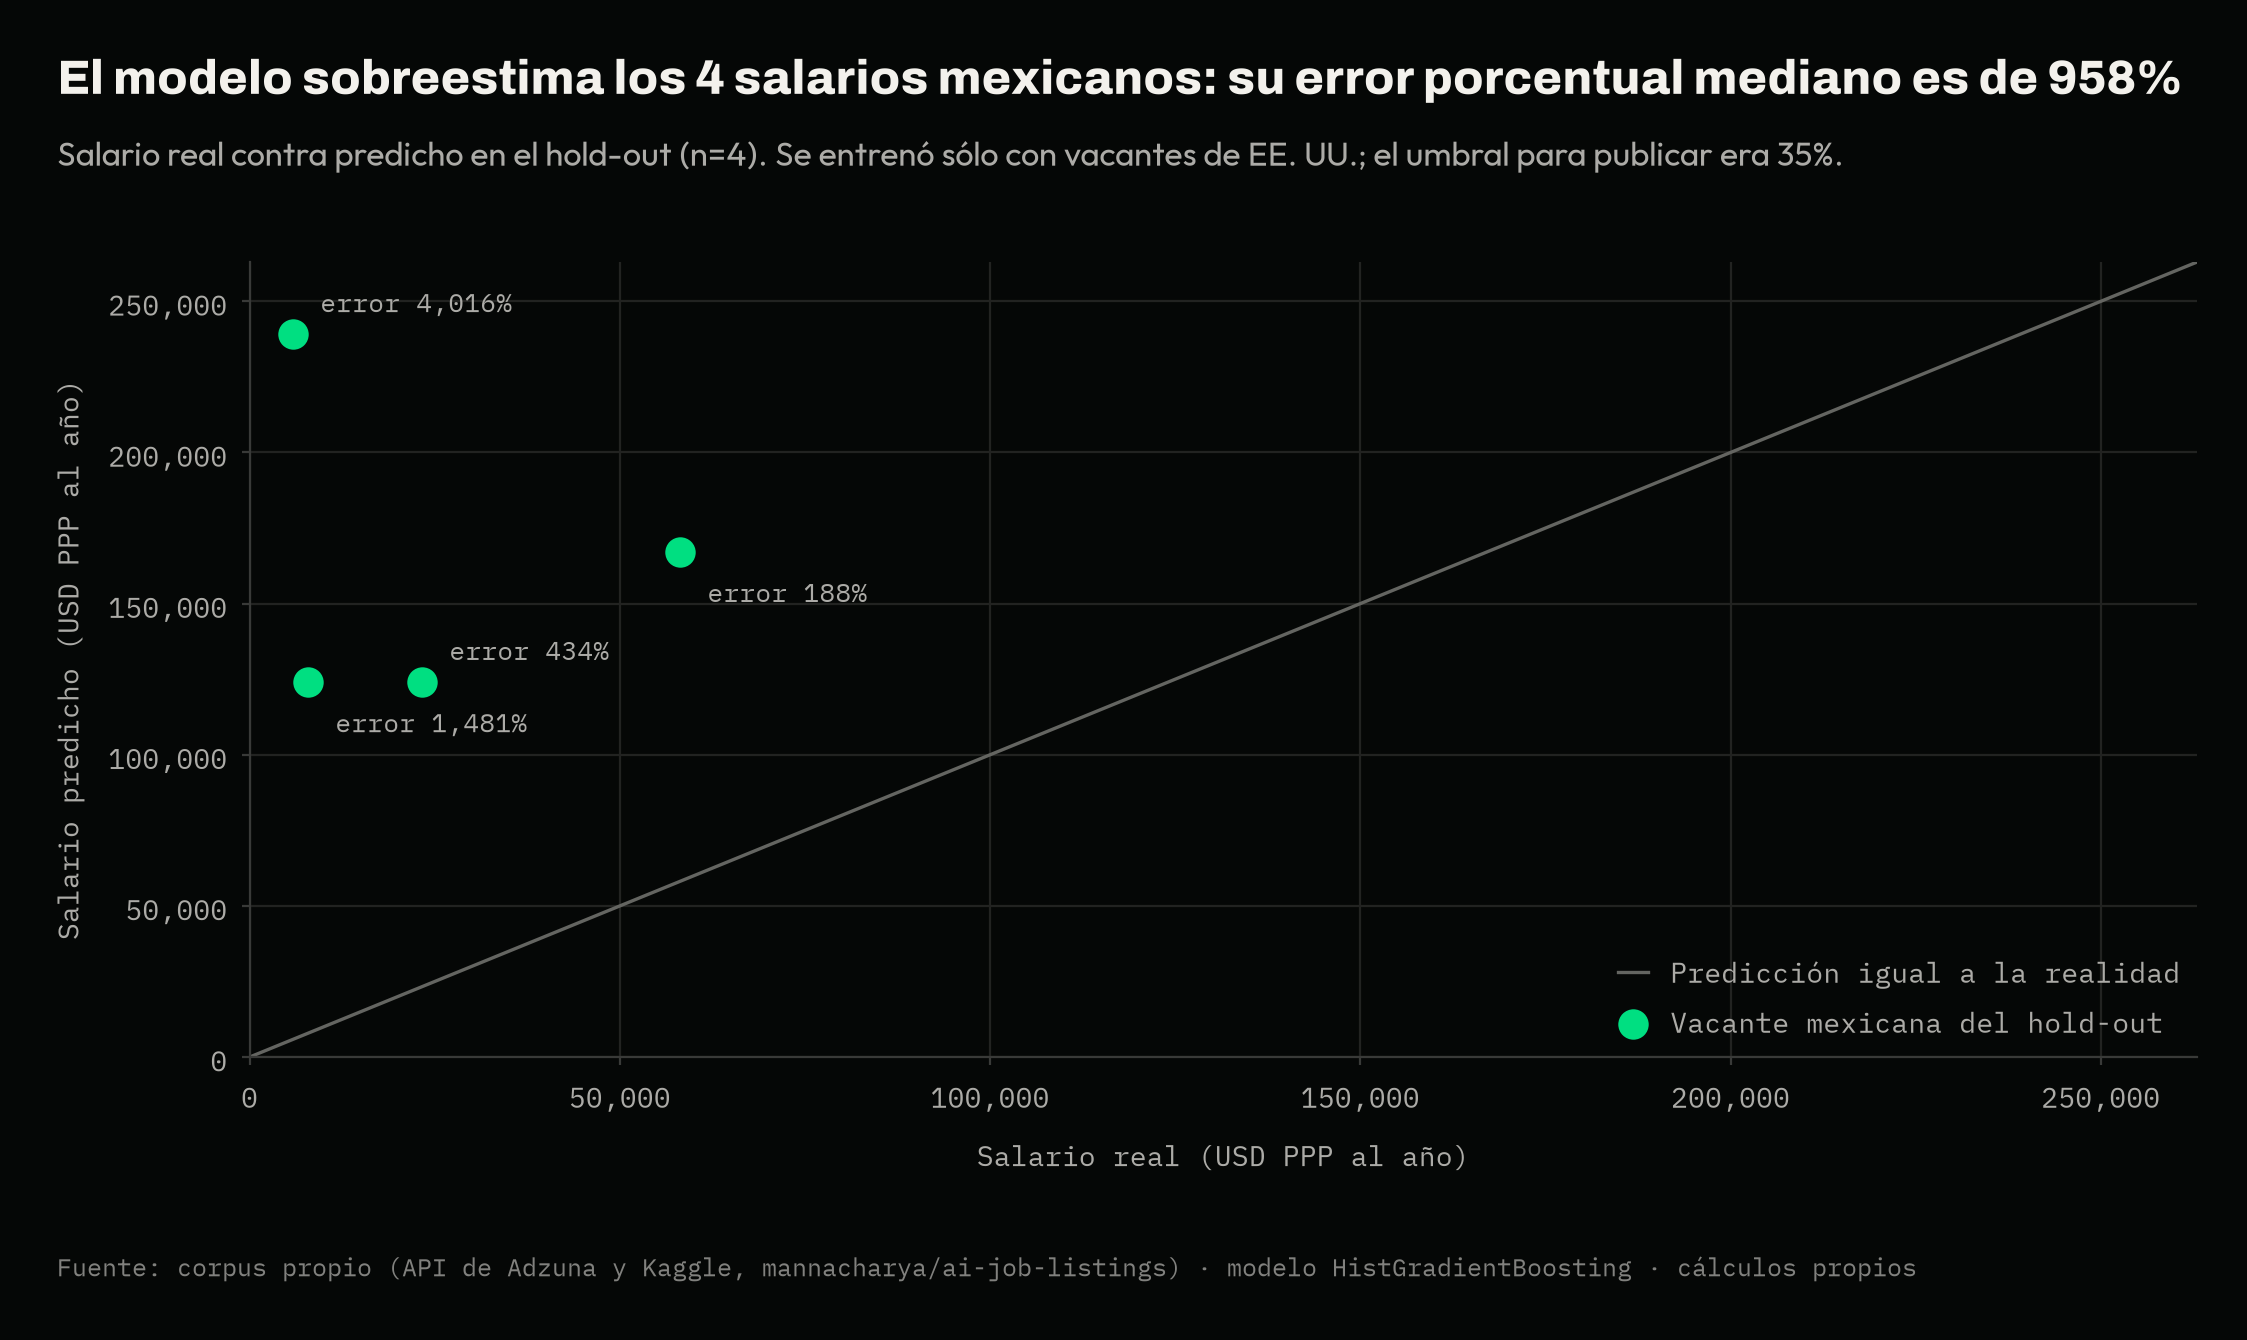

In [8]:
from src.models.evaluate import UMBRAL_MDAPE

pred = modelo.predict(holdout)
real = holdout[TARGET].to_numpy(float)
errores = np.abs(real - pred) / real
verbo = f"sobreestima los {len(holdout)} salarios mexicanos" if (pred > real).all() else f"falla con los {len(holdout)} salarios mexicanos"

fig, ax = plt.subplots(figsize=(11, 6.6))
lim = [0, max(real.max(), pred.max()) * 1.1]
ax.plot(lim, lim, color=PALETA["neutro"], linewidth=1.2, label="Predicción igual a la realidad")
ax.scatter(real, pred, s=120, color=PALETA["verde"], zorder=3, label="Vacante mexicana del hold-out")
# Etiquetas alternadas arriba y abajo: dos vacantes tienen casi la misma predicción.
for k, i in enumerate(np.argsort(real)):
    ax.annotate(f"error {errores[i] * 100:,.0f}%", (real[i], pred[i]), textcoords="offset points",
                xytext=(10, 8 if k % 2 == 0 else -18), fontsize=9.5, color=PALETA["tenue"])
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("Salario real (USD PPP al año)")
ax.set_ylabel("Salario predicho (USD PPP al año)")
miles(ax, "x")
miles(ax, "y")
rejilla(ax, "both")
ax.legend(loc="lower right")
componer(
    fig,
    f"El modelo {verbo}: su error porcentual mediano es de {resultado['mdape_modelo']:.0%}",
    f"Salario real contra predicho en el hold-out (n={len(holdout)}). Se entrenó sólo con vacantes de EE. UU.; el umbral para publicar era {UMBRAL_MDAPE:.0%}.",
    FUENTE_MODELO,
)

In [9]:
print(resultado["veredicto"])

NO PUBLICABLE: MdAPE=957.6% supera el umbral de 35%. El modelo entrenado en EE.UU. no transfiere al mercado mexicano; eso se reporta como hallazgo y las estimaciones no se publican.


**Conclusión:** el modelo no se equivoca al azar — sobreestima siempre, y por mucho. Las cuatro
predicciones caen entre 124,000 y 239,000 USD PPP; los cuatro salarios reales van de 5,800 a
58,000. La razón es estructural, no un accidente de la muestra: `country` es una feature del
modelo, pero en el entrenamiento tuvo un único valor («US»), así que nunca hubo con qué aprender
un ajuste por país. Al encontrarse con México como categoría desconocida, el modelo no
«extrapola con cautela»: cae de vuelta en el nivel salarial estadounidense, que es lo único que
conoce. Con `publicable = False`, las estimaciones no se publican.

## Qué mueve el salario

La transferencia a México no se pudo validar, pero eso no invalida lo que el modelo aprendió
sobre el mercado en el que sí tiene datos de sobra. Con cientos de vacantes estadounidenses de IA
con salario observado, «qué mueve el salario en EE.UU.» es una pregunta que sí se puede responder
con solidez — y es un resultado real del proyecto, con o sin México.

,importancia
metro,0.160569
company_posting_count,0.140749
title_norm,0.104099
seniority,0.077178
company_is_multinational,0.067664
category,0.029654
remote_scope,0.025812
tier,0.004983
is_remote,0.000057
skill_agents,0.000000


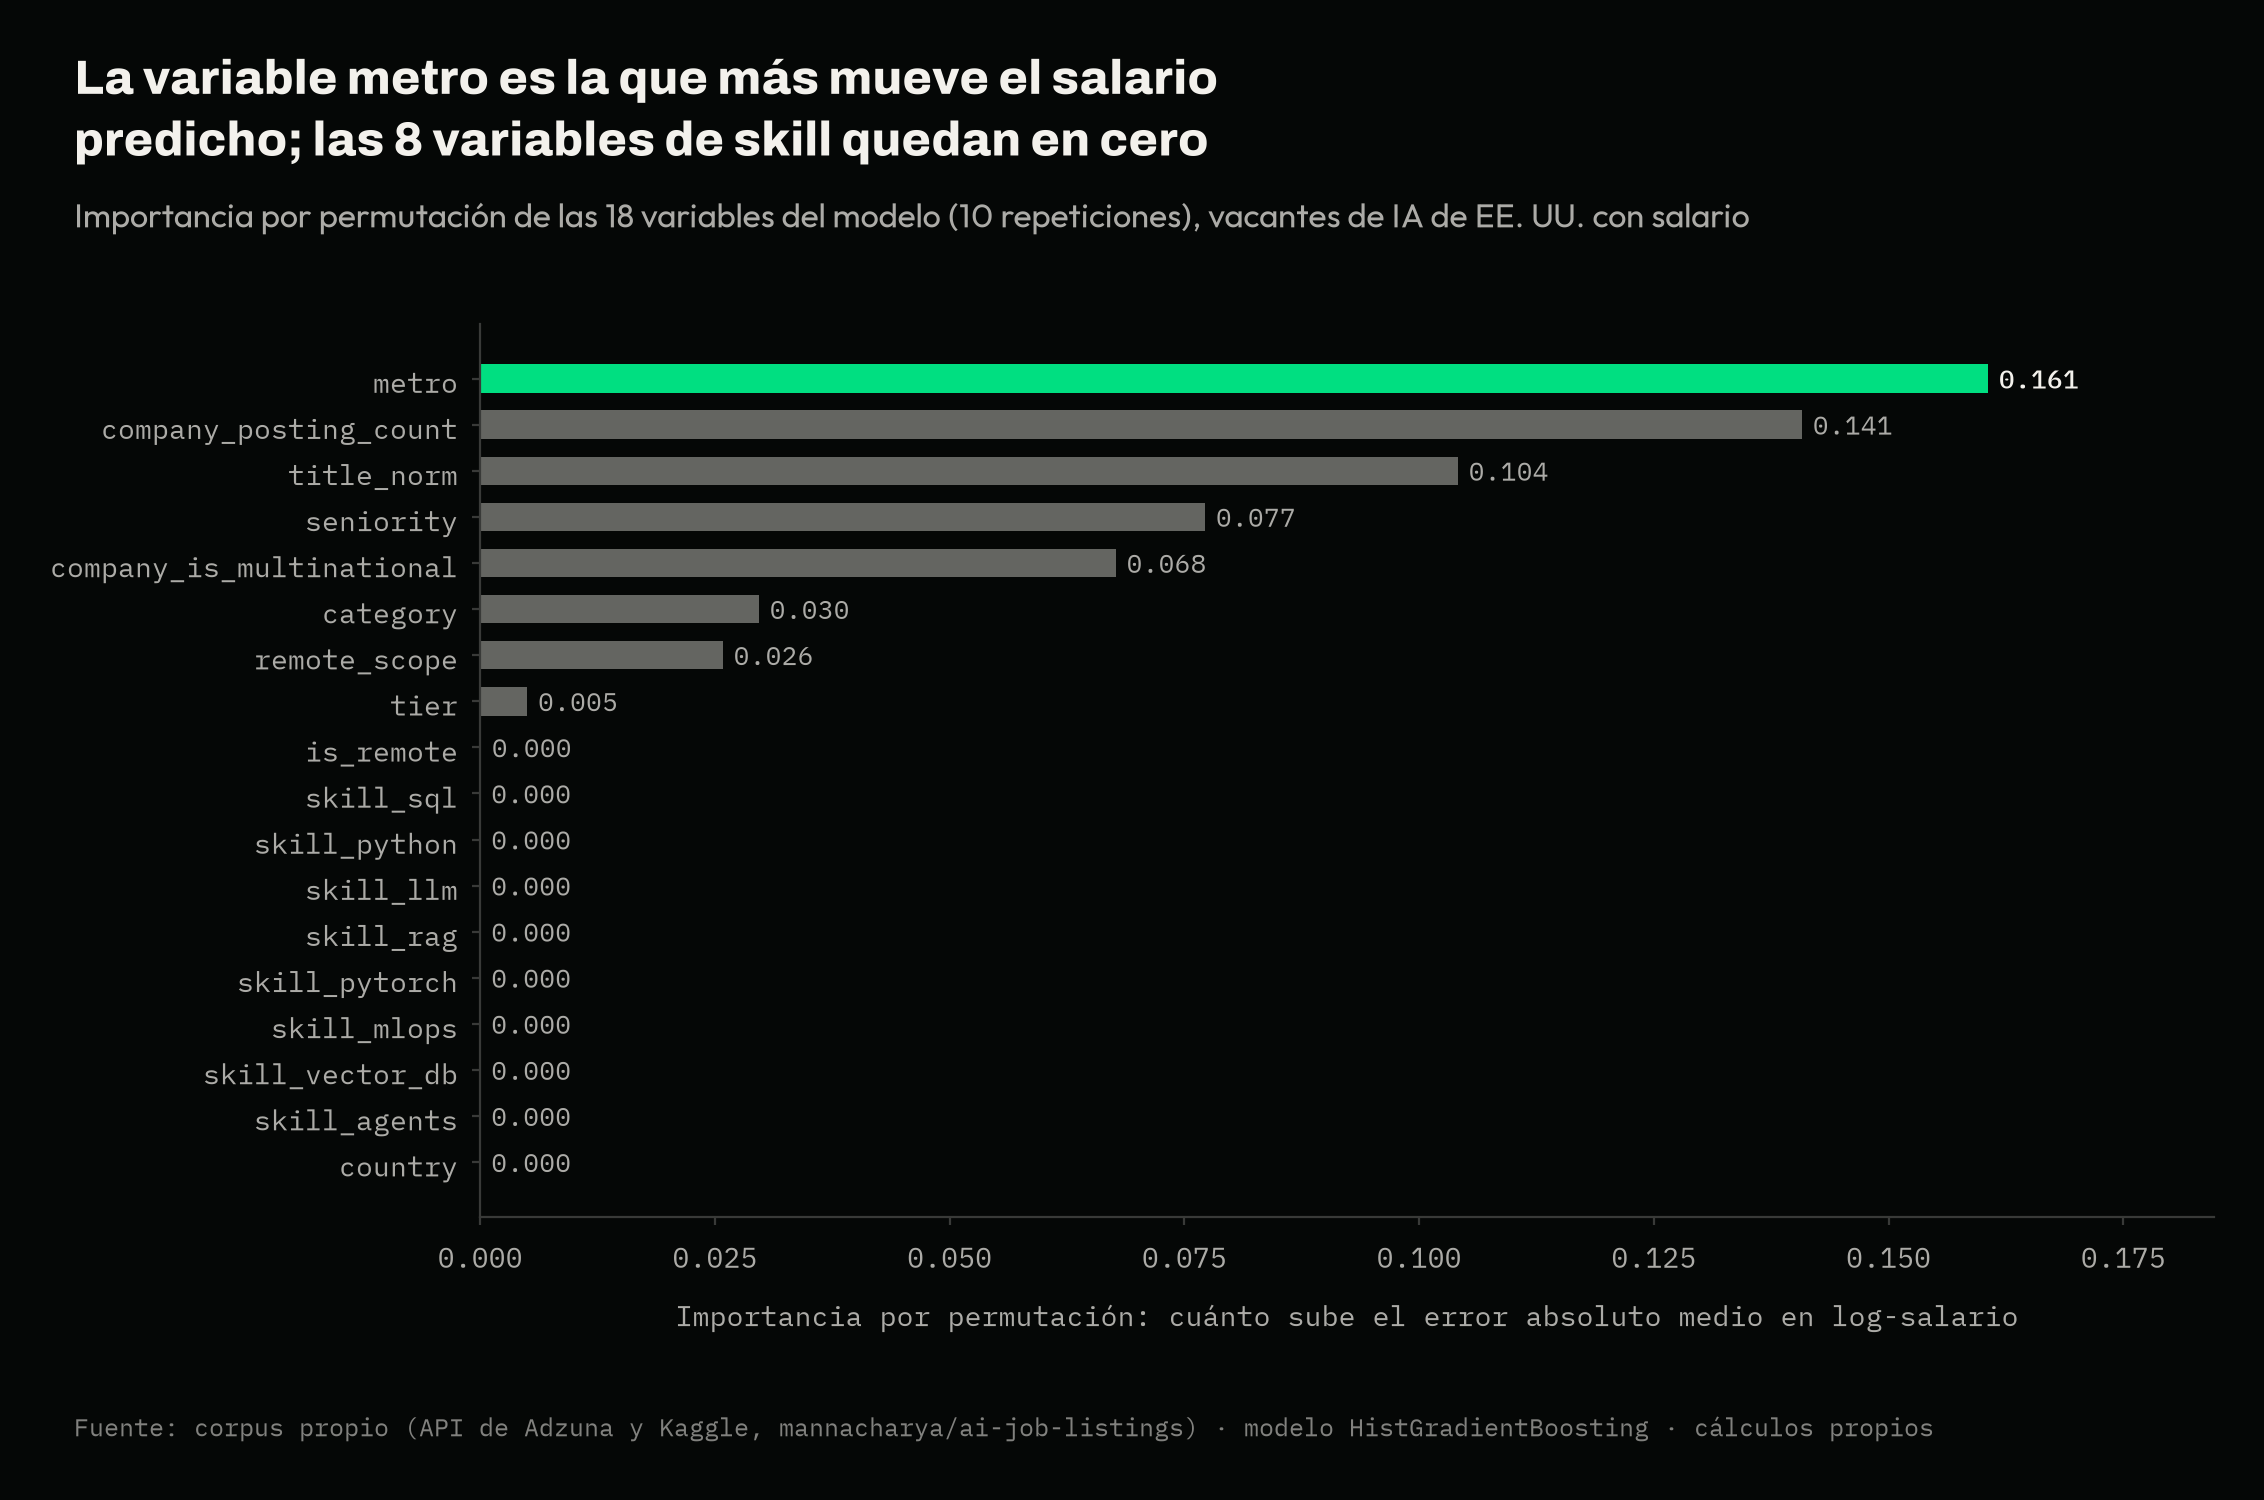

In [10]:
imp = permutation_importance(
    modelo.pipeline, train[FEATURES], np.log(train[TARGET]),
    n_repeats=10, random_state=42, scoring="neg_mean_absolute_error",
)
importancias = pd.Series(imp.importances_mean, index=FEATURES).sort_values()
de_skill = [f for f in FEATURES if f.startswith("skill_")]
en_cero = [f for f in de_skill if abs(importancias[f]) < 0.0005]
cuantas = (f"las {len(de_skill)} variables de skill quedan en cero" if len(en_cero) == len(de_skill)
           else f"{len(en_cero)} de las {len(de_skill)} variables de skill quedan en cero")

fig, ax = plt.subplots(figsize=(11, 7.4))
barras = ax.barh(importancias.index, importancias.values, height=0.62,
                 color=colores(importancias.index, importancias.index[-1]))
etiquetar(ax, barras, [f"{0 if abs(v) < 0.0005 else v:.3f}" for v in importancias.values],
          destacar={len(importancias) - 1})
ax.set_xlim(min(0, importancias.min() * 1.15), importancias.max() * 1.15)
ax.set_xlabel("Importancia por permutación: cuánto sube el error absoluto medio en log-salario")
componer(
    fig,
    f"La variable {importancias.index[-1]} es la que más mueve el salario predicho; {cuantas}",
    f"Importancia por permutación de las {len(FEATURES)} variables del modelo (10 repeticiones), vacantes de IA de EE. UU. con salario",
    FUENTE_MODELO,
)

importancias.sort_values(ascending=False).to_frame("importancia")

Ninguna skill individual entra al top de importancias: `metro`, `company_posting_count`,
`title_norm`, `seniority` y `company_is_multinational` dominan, y las ocho variables de skill
quedan en 0.000 — permutarlas no cambia el error del modelo. Eso no significa que las skills no
importen para el salario; significa que, una vez que el modelo ya sabe el título, el nivel y la
ciudad, no gana nada adicional por saber también qué tecnologías aparecen. La correlación entre
skill y salario es real, pero pasa por el rol y el nivel, no de forma independiente. La comparación
directa lo muestra:

Más alto:  agents ($200,000, n=251)
Más bajo:  prompt_eng ($138,950, n=58)


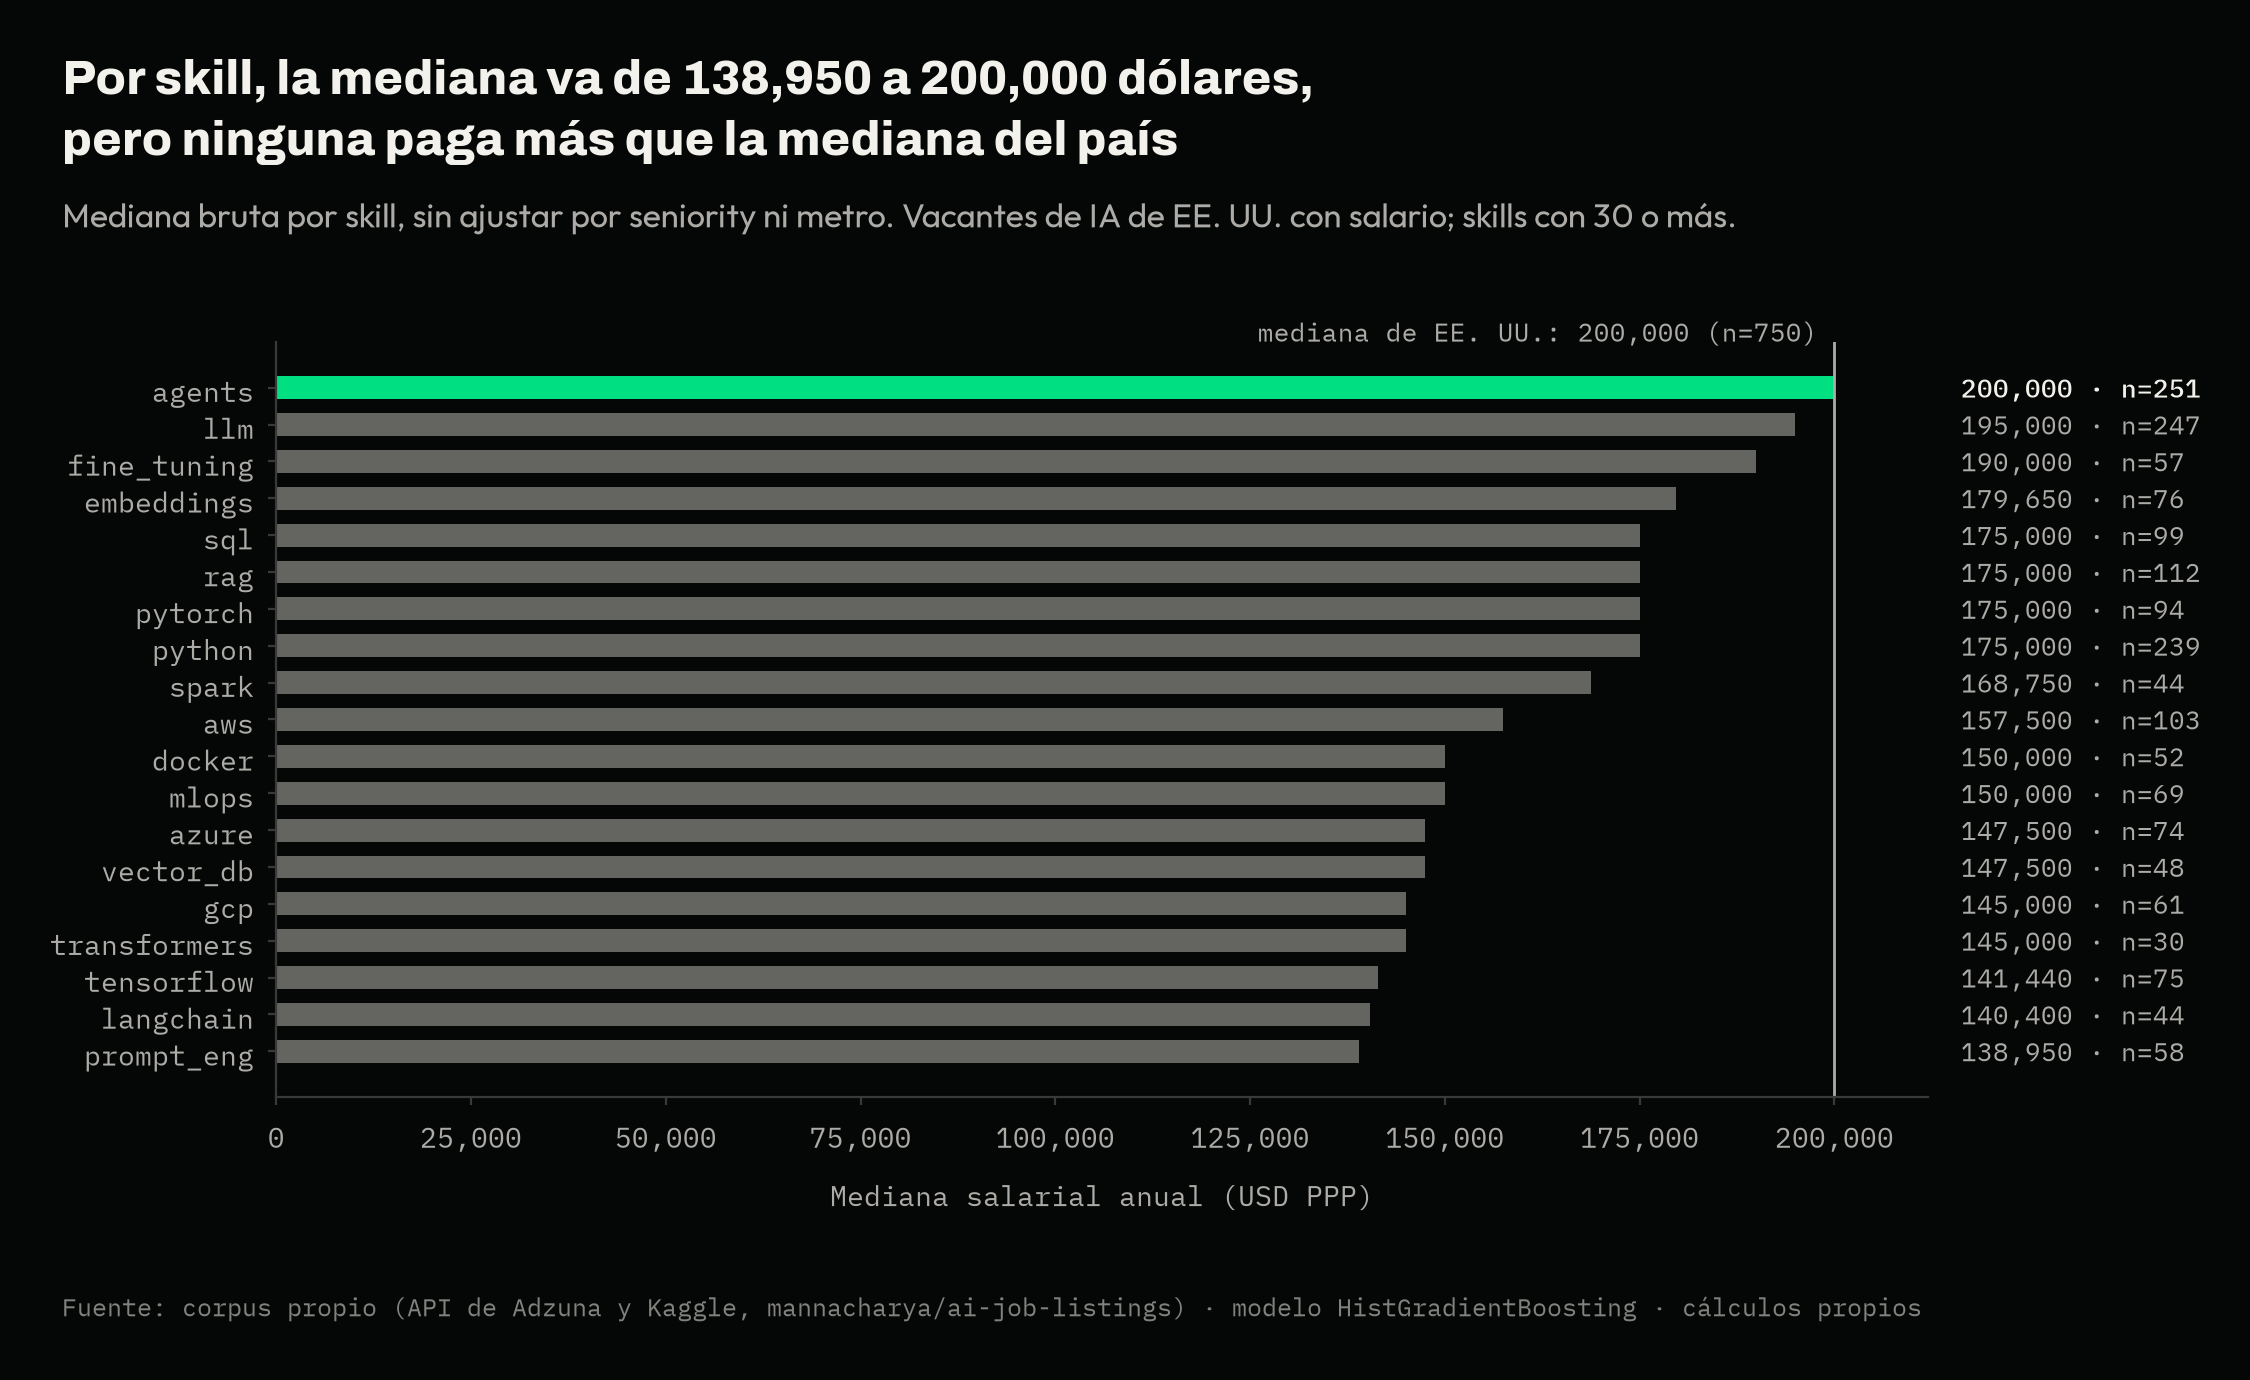

In [11]:
exploded = (
    ia[(ia["country"] == "US") & ia["salary_observed"]]
    .explode("skills")
    .dropna(subset=["skills"])
)
premium = (
    exploded.groupby("skills")[TARGET]
    .agg(n="count", mediana="median")
    .query("n >= 30")
    .sort_values("mediana")
)
mediana_us = ia.loc[(ia["country"] == "US") & ia["salary_observed"], TARGET].median()
n_mediana_us = int(((ia["country"] == "US") & ia["salary_observed"]).sum())
ninguna_encima = not (premium["mediana"] > mediana_us).any()

fig, ax = plt.subplots(figsize=(11, 6.8))
ax.barh(premium.index, premium["mediana"], color=colores(premium.index, premium.index[-1]), height=0.62)
# Los valores van en una columna fuera del área de trazo para que la línea de referencia no los cruce.
tope = len(premium) - 1
for i, (m, n) in enumerate(zip(premium["mediana"], premium["n"])):
    ax.text(1.02, i, f"{m:,.0f} · n={n}", transform=ax.get_yaxis_transform(), va="center", fontsize=9.5,
            color=PALETA["tinta"] if i == tope else PALETA["tenue"], fontweight=500 if i == tope else 400)
ax.axvline(mediana_us, color=PALETA["tenue"], linewidth=1)
ax.annotate(f"mediana de EE. UU.: {mediana_us:,.0f} (n={n_mediana_us:,})", (mediana_us, len(premium) - 0.4),
            xytext=(-6, 6), textcoords="offset points", ha="right", va="bottom", fontsize=9.5, color=PALETA["tenue"])
ax.set_xlim(0, max(premium["mediana"].max(), mediana_us) * 1.06)
ax.set_xlabel("Mediana salarial anual (USD PPP)")
miles(ax, "x")
remate = "ninguna paga más que la mediana del país" if ninguna_encima else "algunas superan la mediana del país"
componer(
    fig,
    f"Por skill, la mediana va de {premium['mediana'].iloc[0]:,.0f} a {premium['mediana'].iloc[-1]:,.0f} dólares, pero {remate}",
    "Mediana bruta por skill, sin ajustar por seniority ni metro. Vacantes de IA de EE. UU. con salario; skills con 30 o más.",
    FUENTE_MODELO,
)

print(f"Más alto:  {premium.index[-1]} (${premium['mediana'].iloc[-1]:,.0f}, n={premium['n'].iloc[-1]})")
print(f"Más bajo:  {premium.index[0]} (${premium['mediana'].iloc[0]:,.0f}, n={premium['n'].iloc[0]})")

**Conclusión:** el rango bruto entre skills es grande —de $138,950 (`prompt_eng`) a $200,000
(`agents`), un spread de USD 61,050— pero no es la señal que parece a primera vista: `agents` no
carga una prima, está exactamente en la mediana nacional, mientras que `prompt_eng` y `langchain`
quedan cerca de 30% por debajo del mercado (nota de método: son medianas univariadas, sin ajustar
por seniority). Y ni siquiera esa relación es incremental: los puestos que piden `agents` también
tienden a ser de mayor seniority, en metros más caros y en empresas distintas, y el modelo ya
captura eso a través de `title_norm`, `seniority` y `metro`. La estructura salarial estadounidense
de IA está gobernada por el rol, el nivel y la ubicación; la lista de tecnologías es, en el mejor
de los casos, redundante con esas tres cosas.

## Resumen del modelo

**Veredicto:** `publicable = False`.

> NO PUBLICABLE: MdAPE=957.6% supera el umbral de 35%. El modelo entrenado en EE.UU. no
> transfiere al mercado mexicano; eso se reporta como hallazgo y las estimaciones no se publican.

El modelo, entrenado sobre 750 vacantes estadounidenses de IA con salario observado, erró un
958 % (MdAPE) sobre las 4 vacantes mexicanas con salario real que existen en el corpus — muy por
encima del umbral de 35 % del spec. Superó al baseline ingenuo (mediana por seniority, que erró
1,606 %), pero ganarle a un rival igualmente perdido no acerca la conclusión a publicable. Ningún
salario imputado para México sale de este notebook.

El punto que vale la pena dejar explícito no es «el modelo falló». Es más fuerte que eso: **con 4
observaciones no hay manera de validar la transferencia, sin importar qué tan bueno o malo sea el
modelo.** Un modelo genuinamente bueno no podría haberse demostrado bueno con cuatro puntos
—cualquier cuarteto de salarios reales, típico o atípico, cabe dentro del ruido de muestra—, y uno
malo, como este, tampoco puede descartarse con la contundencia que darían 30 o 300 observaciones.
La barrera no es sólo que el modelo probablemente no transfiera entre mercados —de hecho hay una
razón estructural concreta para que no transfiera: `country` fue una constante durante el
entrenamiento («US»), así que el modelo nunca tuvo con qué aprender un desnivel entre países, y al
encontrarse con México como categoría desconocida cae de vuelta al nivel salarial estadounidense,
que es lo único que conoce—. La barrera real es que **no existe, con los datos de hoy, un
experimento capaz de demostrar lo contrario.** Un modelo cuya precisión no se puede medir no debe
publicar sus estimaciones, sin importar cuán razonable parezca su lógica interna.

Este notebook no bajó el umbral del 35 %, no coló vacantes mexicanas al entrenamiento para
inflar el hold-out, y no cambió de métrica cuando el MdAPE no alcanzó. Un proyecto que sabe cuándo
callarse vale más que uno que siempre tiene un número, y eso es, con todo, un resultado: la
respuesta a «por qué es tan difícil averiguar cuánto paga la IA en México» no termina en que las
empresas no publican el sueldo — sigue hasta que ni un modelo entrenado con seriedad sobre un
mercado bien medido tiene manera de llenar ese vacío mientras México aporte cuatro salarios
observables.

Lo que sí se sostiene, con o sin México, es la mitad estadounidense del ejercicio: con validación
cruzada, el modelo explica el salario de una vacante de IA en EE.UU. con un MdAPE de 28.4 %, y lo
que más mueve esa predicción es el metro, el volumen de vacantes de la empresa, el título
normalizado, la seniority y si la empresa es multinacional — no la lista de skills, que compite
por el salario a través del rol que ocupa y no de forma independiente. Es una respuesta real a
«qué mueve el salario de IA», incluso cuando la pregunta original —cuánto paga México— tiene que
quedarse, por ahora, sin número.

## Qué cambió en el pipeline después de este veredicto

El diagnóstico de arriba no se quedó en diagnóstico. `country` era una feature con un único
valor durante el entrenamiento, y esa es una causa concreta con un arreglo concreto. El pipeline
ya lo tiene montado:

- **Países de calibración** (`config/countries.yml`). Diez países de Adzuna entran al corpus con
  una malla nacional acotada, elegidos para cubrir el rango de niveles de precio: India, Sudáfrica,
  Brasil y Polonia por debajo de Estados Unidos; Suiza, Alemania y Reino Unido por encima. Con eso
  `country` deja de ser una constante y el modelo puede aprender un desnivel entre mercados en vez
  de tratar a México como una categoría desconocida.
- **Dos fuentes estadounidenses con salario real al 100 %**: USAJOBS y los archivos de divulgación
  LCA del Departamento del Trabajo. Suben el volumen del lado que sí se puede entrenar.
- **Un agregador mexicano con compuerta** (Jooble). Es el único camino para que el hold-out crezca
  de 4 hacia el n ≥ 30 que pide el criterio del proyecto. Su salario viene en texto libre y mezcla
  importes del empleador con estimaciones del portal, así que pasa por `salario_texto.parsear`,
  que ante cualquier duda lo marca como predicho.
- **Anclas oficiales** (`src/analysis/anclas.py`): IMSS e INEGI para México, BLS para Estados
  Unidos. Permiten separar el nivel nacional, que no transfiere, de la posición relativa dentro del
  país, que sí puede transferir y sí se puede validar contra muchos países.

**Lo que esto no cambia todavía.** Las cifras de este notebook —el 957.6 %, el hold-out de 4 filas,
las 750 vacantes de entrenamiento— corresponden al corpus con el que se ejecutó. Ninguna de ellas
se mueve hasta que corra una recolección nueva con las fuentes de arriba y se reconstruya el
parquet. Dejarlas escritas como si el arreglo ya hubiera surtido efecto sería exactamente el tipo
de adelanto que este notebook existe para no hacer.

Y el argumento de fondo sigue en pie aunque todo lo anterior funcione: si el hold-out mexicano no
llega a n ≥ 30, la transferencia sigue sin poder validarse, y el modelo sigue sin derecho a
publicar estimaciones. Más fuentes miden mejor la escasez de salarios publicados en México; no la
hacen desaparecer, porque esa escasez es el hallazgo número uno del proyecto.